In this notebook we perform EDA on our dataset to get a feel for the data at hand. 

In [2]:
import os 
from dotenv import load_dotenv
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

# Load the file path. 
load_dotenv()
path = os.getenv("TRAINING_DATA_URL")

# Load the dataset as a pandas df and check the import 
titanic_df = pd.read_csv(path)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Discard the id, name and ticket columns. 
titanic_df_new = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
# Obtain the column types as well as some general information about the data.
print(titanic_df_new.shape)
print(titanic_df_new.dtypes)

(891, 9)
Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object


         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
         Sex Cabin Embarked
count    891   204      889
unique     2   147        3
top     male    G6        S
freq     577     4      644
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    -----------

/var/folders/dq/djx30cqn6nl8bxrcw72yq5t80000gn/T/ipykernel_6124/2984516083.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(titanic_df_new.describe(include=np.object_))


<Axes: xlabel='Survived'>

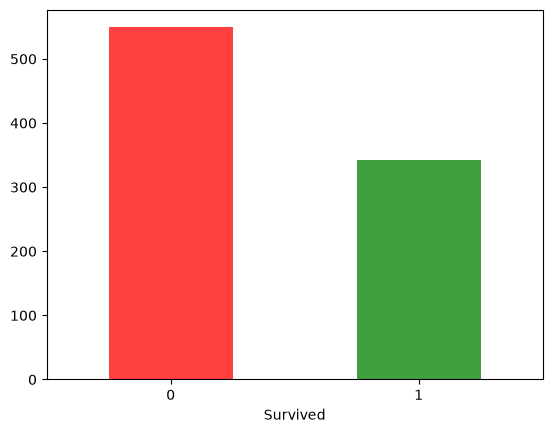

In [4]:
# General Information 
print(titanic_df_new.describe())
print(titanic_df_new.describe(include=np.object_))
print(titanic_df_new.info())
print(titanic_df_new["Survived"].value_counts(normalize=True))
titanic_df_new["Survived"].value_counts().plot.bar(color=['red','green'], y="Count", rot=0, alpha=0.75)

In [5]:
# Lets compute the distribution of sex.
pd.DataFrame(data=[titanic_df_new["Sex"].value_counts(), 
                   round(titanic_df_new["Sex"].value_counts(normalize=True), 2) * 100])

Sex,male,female
count,577.0,314.0
proportion,65.0,35.0


In [6]:
# Out of curiosity lets check what was the busiest maritime passenger terminal.
pd.DataFrame(data=[titanic_df_new["Embarked"].value_counts(), 
                   round(titanic_df_new["Embarked"].value_counts(normalize=True), 2) * 100])

Embarked,S,C,Q
count,644.0,168.0,77.0
proportion,72.0,19.0,9.0


Age_group        adult   children   teenager    elderly
count       588.000000  69.000000  44.000000  13.000000
proportion    0.823529   0.096639   0.061625   0.018207


<Axes: title={'center': 'Distribution of Age Groups'}, xlabel='Age Group'>

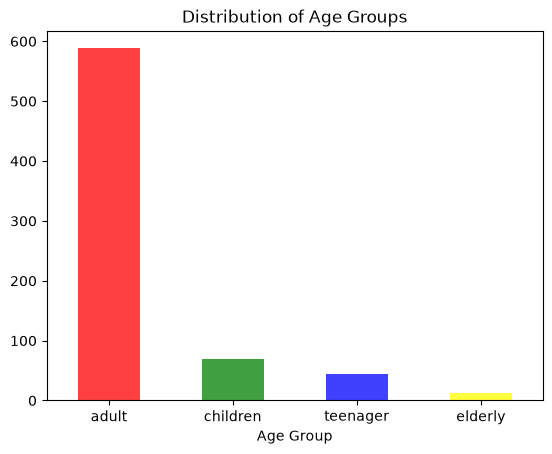

In [7]:
# Group the ages into bin and observe their distribution.
titanic_df_new['Age_group'] = pd.cut(titanic_df_new['Age'], bins=[0, 12, 17, 63, titanic_df_new['Age'].max()], labels=['children', 'teenager', 'adult', 'elderly'])
print(pd.DataFrame(data = [titanic_df_new['Age_group'].value_counts(),
      titanic_df_new['Age_group'].value_counts(normalize=True)]))

titanic_df_new["Age_group"].value_counts().plot.bar(color=['red','green', 'blue', 'yellow'], y="Count", rot=0, alpha=0.75, title='Distribution of Age Groups', xlabel='Age Group')

In [8]:
# Get the survival rate per age group.
pd.concat([titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(),
           titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(normalize=True)], axis=1)

count  proportion
Age_group Survived                   
children  1            40    0.579710
          0            29    0.420290
teenager  0            23    0.522727
          1            21    0.477273
adult     0           360    0.612245
          1           228    0.387755
elderly   0            12    0.923077
          1             1    0.076923

Text(0, 0.5, 'Frequency')

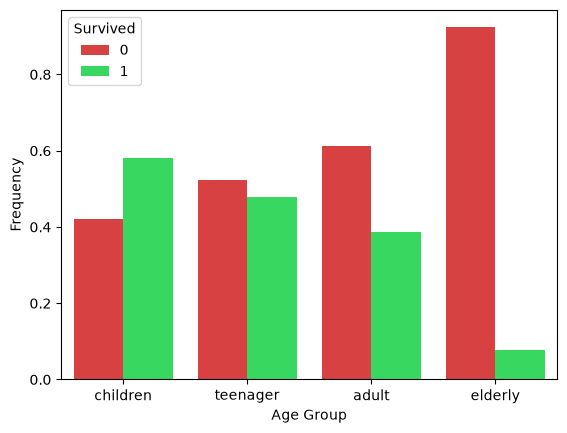

In [27]:
# Plot the distribution of survival by age.
import seaborn as sns 
ax = sns.barplot(
    x="Age_group",
    y="proportion",
    hue="Survived",
    data=titanic_df_new[['Age_group','Survived']].groupby("Age_group").value_counts(normalize=True).reset_index(), 
    palette={0: "#f02828", 1: "#1ef153"}
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Frequency")

In [28]:
# Get the survival rate per sex.
pd.concat([titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(),
           titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(normalize=True)], axis=1)


count  proportion
Sex    Survived                   
female 1           233    0.742038
       0            81    0.257962
male   0           468    0.811092
       1           109    0.188908

Text(0, 0.5, 'Frequency')

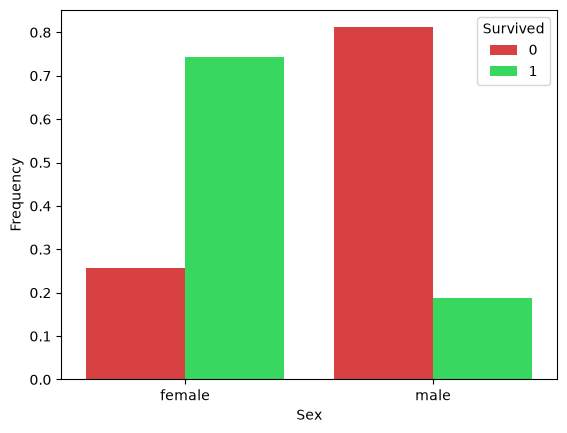

In [29]:
# Plot the distribution of survival by sex.
import seaborn as sns 
ax = sns.barplot(
    x="Sex",
    y="proportion",
    hue="Survived",
    data=titanic_df_new[['Sex','Survived']].groupby("Sex").value_counts(normalize=True).reset_index(), 
    palette={0: "#f02828", 1: "#1ef153"}
)

ax.set_xlabel("Sex")
ax.set_ylabel("Frequency")

In [ ]:
# Lets compute the correlation matrix.

Age_group  Survived
children   1           0.579710
           0           0.420290
teenager   0           0.522727
           1           0.477273
adult      0           0.612245
           1           0.387755
elderly    0           0.923077
           1           0.076923
Name: proportion, dtype: float64